$$\Huge \text{Øving 10 - Havnivå}$$
$$\Large \text{Simen Roko Krogstie}$$

In [1]:
# Importerer nødvendlige bibliotek
import matplotlib.pyplot as plt
import numpy as np

#### **Last inn månedlige vannstandsdata fra vannstandsmåleren i Oslo**

In [2]:
tgdata = np.loadtxt("62.rlrdata.txt", dtype=(float), delimiter=";")


#### **2. Lag en figur som viser datasettet**

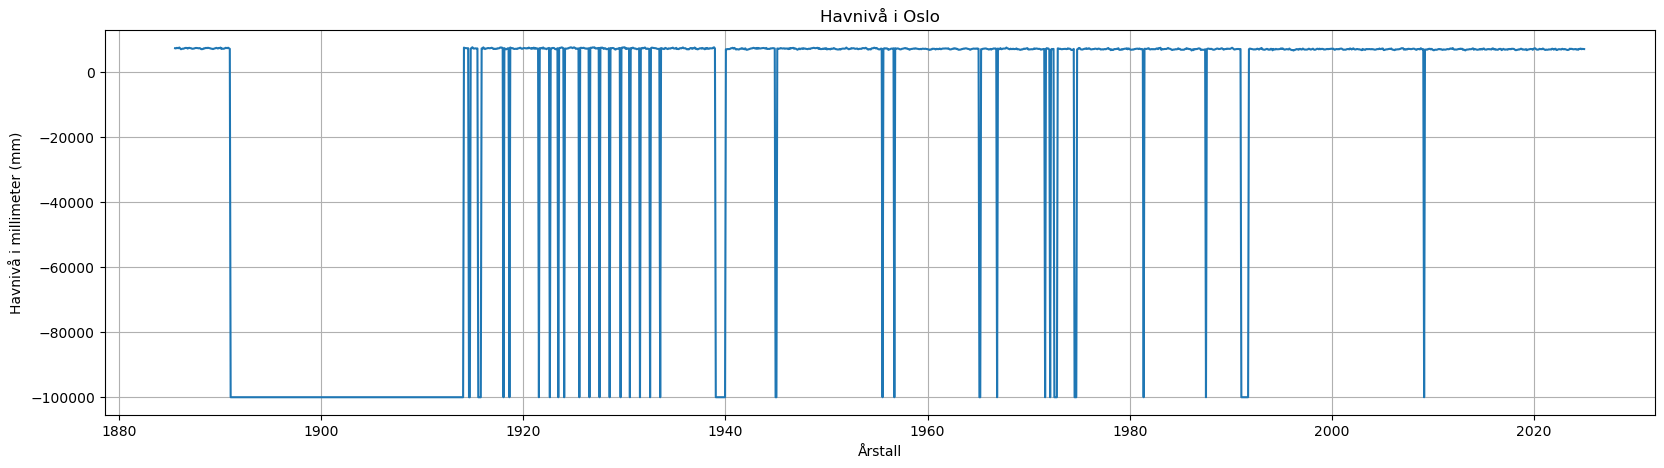

In [3]:
fig = plt.figure(figsize=(20, 5))                                 
plt.plot(tgdata[:, 0], tgdata[:, 1])   
plt.title("Havnivå i Oslo")     
plt.xlabel("Årstall")                              
plt.ylabel("Havnivå i millimeter (mm)")          
plt.grid(True)                                         
plt.show()                                         

#### **3. Visuell inspelsjon/prosessering av data**

Fra figuren over ser vi at det er flere manglende observasjoner av vannstanden i Oslo, da dette er lagt inn med verdien -99999 i datasettet. Disse fjerner vi enkelt slik:

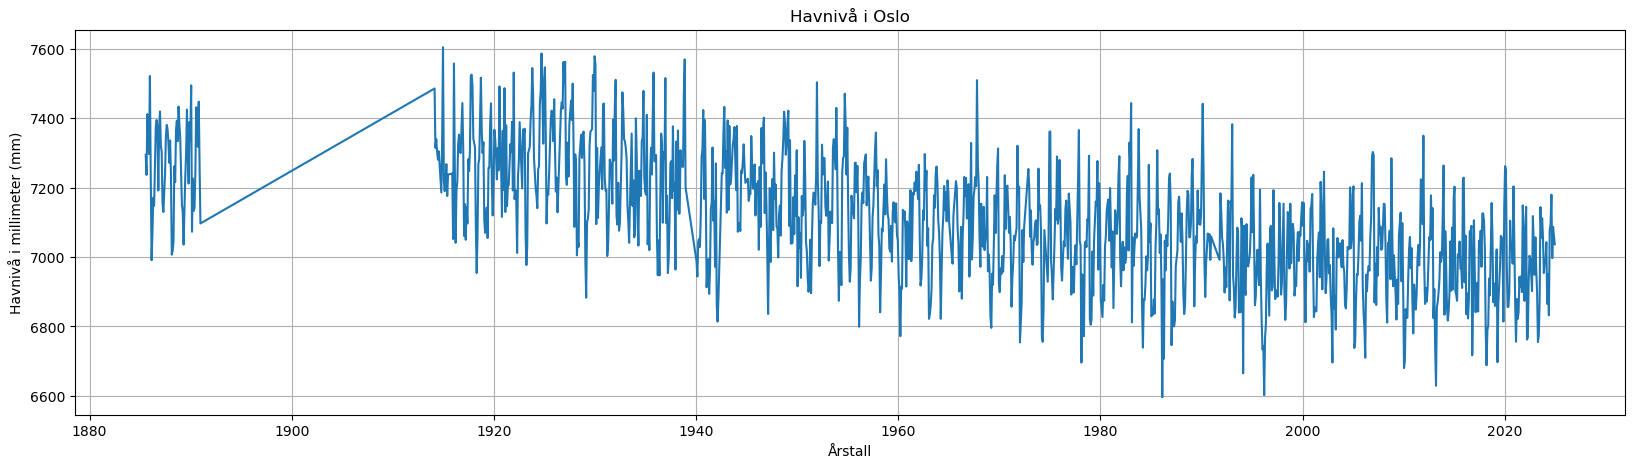

In [4]:
# Fjerner manglende observasjoner
tgdata = tgdata[tgdata[:, 1] != -99999] 

# Plotter ny figur
plt.figure(figsize=(20, 5))
plt.plot(tgdata[:, 0], tgdata[:, 1])
plt.title("Havnivå i Oslo")     
plt.xlabel("Årstall")                              
plt.ylabel("Havnivå i millimeter (mm)") 
plt.grid(True)
plt.show()

De manglende observasjonene er nå fjernet, men det er et stort gap i tid mellom observasjoner mellom ca 1890 og 1915. Derfor fjerner vi observasjoner fra før 1915.

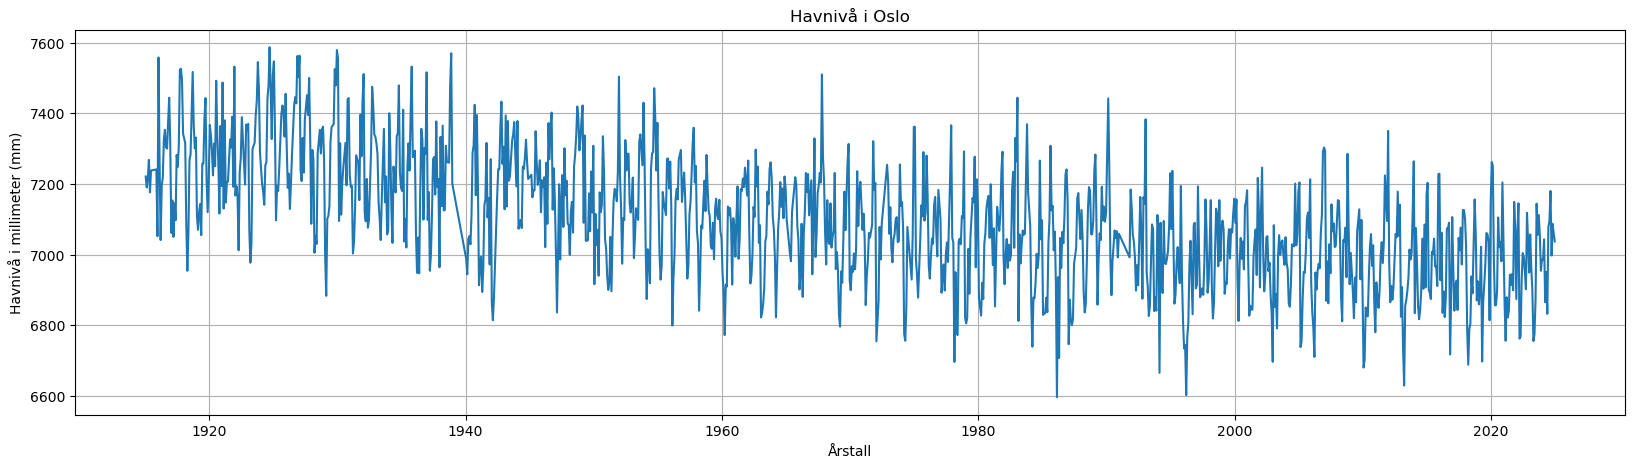

In [5]:
# Fjerner observasjoner fra før 1915
tgdata = tgdata[tgdata[:, 0] >= 1915] 

plt.figure(figsize=(20, 5))
plt.plot(tgdata[:, 0], tgdata[:, 1])
plt.title("Havnivå i Oslo")     
plt.xlabel("Årstall")                              
plt.ylabel("Havnivå i millimeter (mm)") 
plt.grid(True)
plt.show()

#### **4. Beregn en lineær trend basert på det endelige datasettet**

In [6]:
# y = ax + b
a, b = np.polyfit(tgdata[:, 0], tgdata[:, 1], 1)               # Beregner stigningstall (a) og skjæringspunkt (b) for trendlinjen   
print(f'Lineær trendlinje: y = {a:.2f}x + {b:.2f}')

Lineær trendlinje: y = -3.25x + 13501.42


#### **5. Plott trenden i en figur og bestem S_tg**

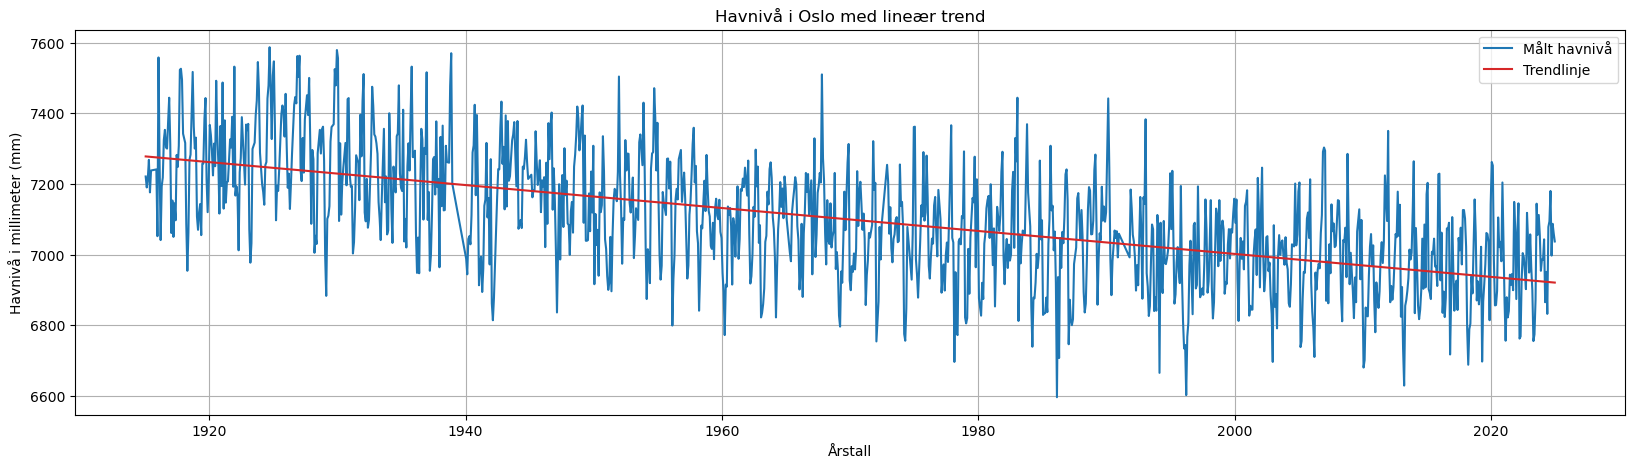

Endring i havnivå (S_tg) = -3.25 mm/år


In [7]:
# Trendlinjen
trend = a * tgdata[:, 0] + b                                

plt.figure(figsize=(20, 5))     
plt.plot(tgdata[:,0], tgdata[:,1], label="Målt havnivå")
plt.plot(tgdata[:, 0], trend, label="Trendlinje", color="tab:red")
plt.title("Havnivå i Oslo med lineær trend")
plt.ylabel("Havnivå i millimeter (mm)")
plt.xlabel("Årstall")
plt.legend()
plt.grid(True)
plt.show()

print(f'Endring i havnivå (S_tg) = {a:.2f} mm/år')

Jeg forventet at trenden skulle være negativ da jeg ikke har tatt høyde for landhevingen i Norge. Det gir derfor mening at denne trenden viser at havnivået synker.

#### **6. Bestem GIA-korrigert havnivåendring for vannstandsmåleren i Oslo**

In [8]:
# Landheving i millimeter per år
S_gpselev = +4.6

# Endring i geoidens høyde per år
S_geoidGIA = +0.4   

# GIA-korrigert havnivåendring i millimeter per år
S_giacorr = a + S_gpselev - S_geoidGIA
print(f'GIA-korrigert havnivåendring for vannstandsmåleren i Oslo = {S_giacorr:.2f} mm/år')

GIA-korrigert havnivåendring for vannstandsmåleren i Oslo = 0.95 mm/år


##### Kommentar:

 Når vi tar høyde for landheving og endring i geoidens høyde blir målet på havnivåendringen et absolutt, globalt mål. At vi får en positiv trend gir stemmer med forventningen om at havnivået stiger globalt, selv om det relative havnivået i Oslo synker på grunn av landheving.  